In [1]:
!pip install prophet openpyxl

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
from google.colab import files

uploaded = files.upload()


Saving online_retail_II.xlsx to online_retail_II.xlsx


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

In [7]:
retail = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

telco = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)


In [8]:
print("Retail Dataset Shape:")
print(retail.shape)

print("\nTelco Dataset Shape:")
print(telco.shape)

Retail Dataset Shape:
(541910, 8)

Telco Dataset Shape:
(7043, 21)


In [9]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
print("Retail Missing Values")
print(retail.isnull().sum())

print("\nTelco Missing Values")
print(telco.isnull().sum())

Retail Missing Values
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

Telco Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
retail = retail.dropna(
    subset=["Customer ID"]
)

retail = retail.drop_duplicates()

In [13]:
telco["TotalCharges"] = pd.to_numeric(
    telco["TotalCharges"],
    errors="coerce"
)

telco = telco.dropna()

In [14]:
retail["Revenue"] = (
    retail["Quantity"]
    * retail["Price"]
)

retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


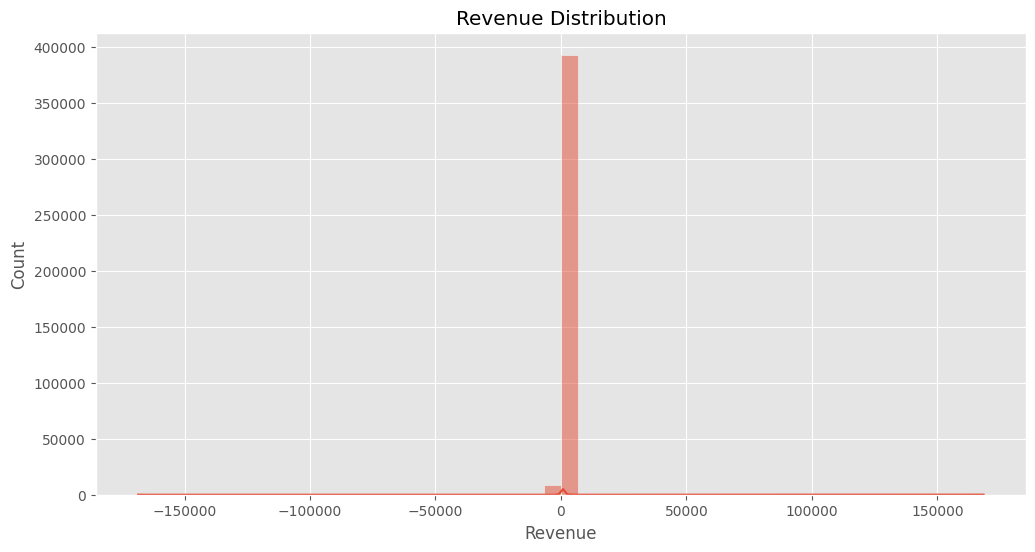

In [15]:
plt.figure(figsize=(12,6))

sns.histplot(
    retail["Revenue"],
    bins=50,
    kde=True
)

plt.title("Revenue Distribution")
plt.show()

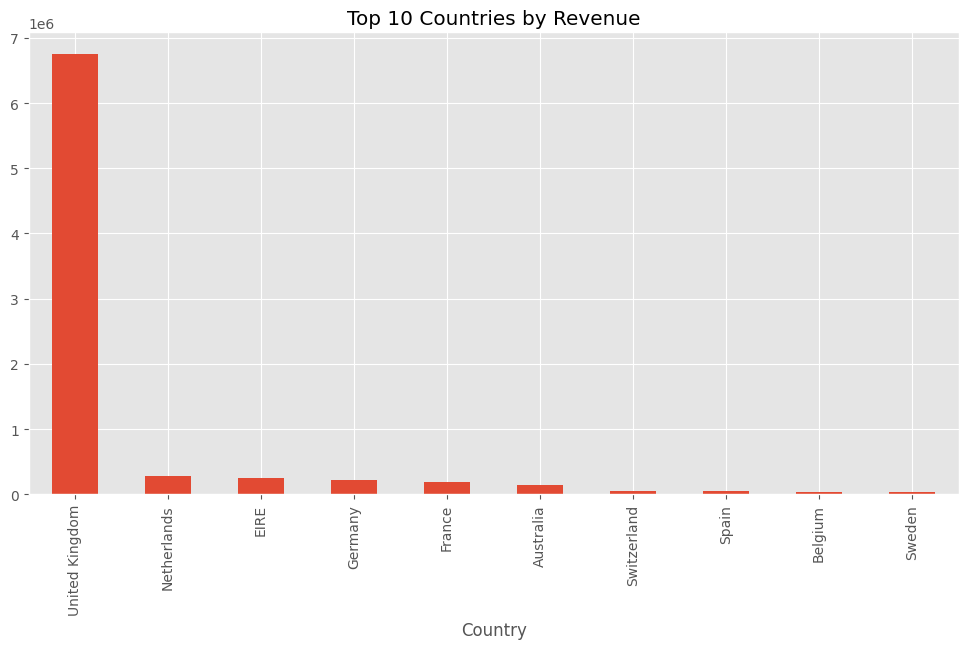

In [16]:
top_countries = (
    retail.groupby("Country")
    ["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_countries.plot(
    kind="bar"
)

plt.title("Top 10 Countries by Revenue")

plt.show()


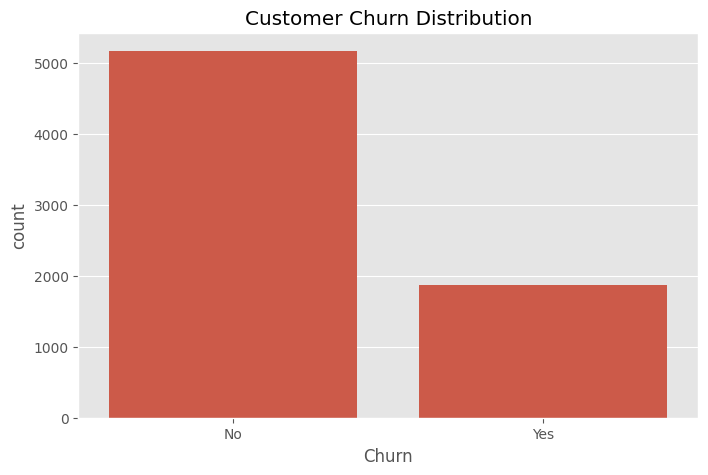

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Churn",
    data=telco
)

plt.title("Customer Churn Distribution")

plt.show()

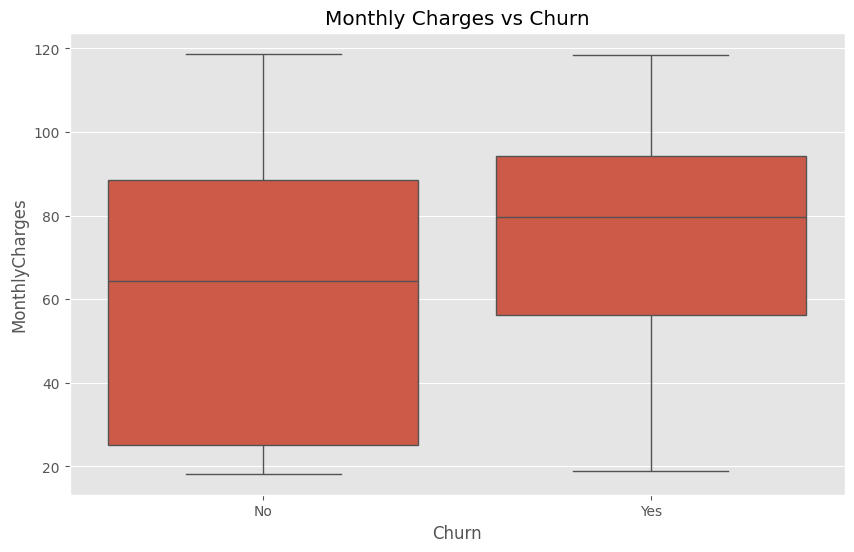

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=telco
)

plt.title(
    "Monthly Charges vs Churn"
)

plt.show()

In [20]:
churn_rate = (
    telco["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [21]:
retail["InvoiceDate"] = pd.to_datetime(
    retail["InvoiceDate"]
)

retail["Month"] = (
    retail["InvoiceDate"]
    .dt.to_period("M")
)

In [22]:
monthly_revenue = (
    retail.groupby("Month")
    ["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Month,Revenue
0,2010-12,552372.860
1,2011-01,473731.900
2,2011-02,435534.070
3,2011-03,578576.210
4,2011-04,425222.671


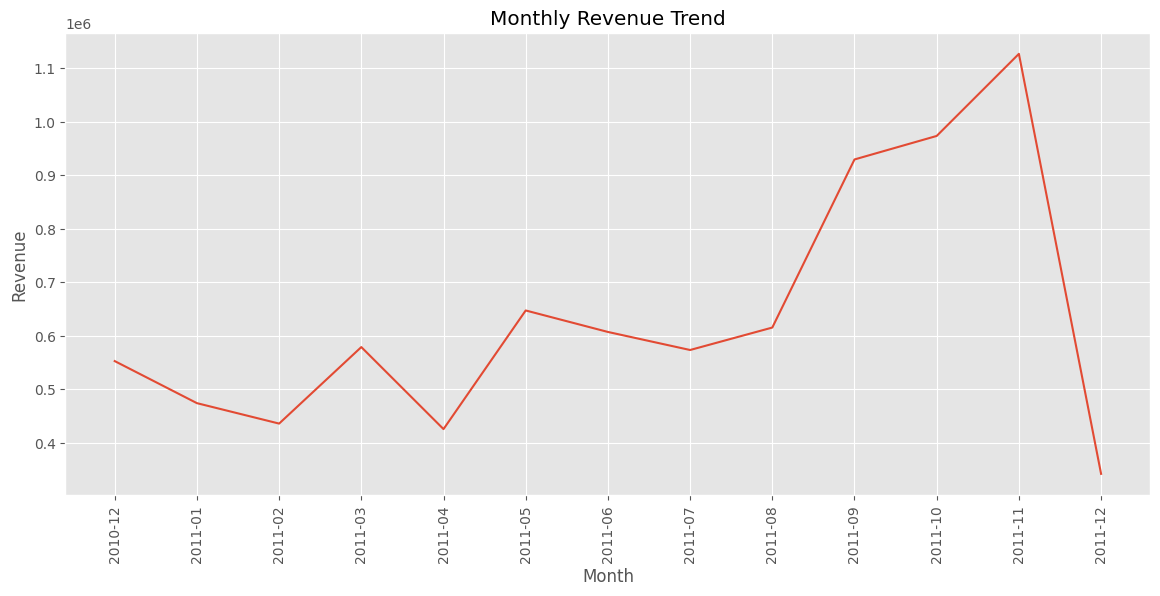

In [23]:
monthly_revenue["Month"] = (
    monthly_revenue["Month"]
    .astype(str)
)

plt.figure(figsize=(14,6))

sns.lineplot(
    x="Month",
    y="Revenue",
    data=monthly_revenue
)

plt.xticks(rotation=90)

plt.title(
    "Monthly Revenue Trend"
)

plt.show()

In [24]:
retail.to_csv(
    "clean_retail.csv",
    index=False
)

telco.to_csv(
    "clean_telco.csv",
    index=False
)

monthly_revenue.to_csv(
    "monthly_revenue.csv",
    index=False
)

print("Files Saved Successfully!")

Files Saved Successfully!


In [25]:
retail.to_csv("clean_retail.csv", index=False)
telco.to_csv("clean_telco.csv", index=False)
monthly_revenue.to_csv("monthly_revenue.csv", index=False)

In [26]:
from google.colab import files

files.download("clean_retail.csv")
files.download("clean_telco.csv")
files.download("monthly_revenue.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>